# Validación

#### Criterio de la hipótesis

**Hipótesis:** el modelo mejora la planificación actual del ERP en al menos un **20 %**.

**Criterio cuantitativo:**       
El modelo seleccionado obtiene un skill score de MAE **≥ 20 %** respecto a **B0** (ratio = 1, planificación del ERP), calculado como `1 − MAE_modelo / MAE_B0`:
- en validación, con la media de los 3 folds (para seleccionar), y en test .

**Comparaciones complementarias** (no forman parte de la hipótesis):     
El skill score frente a B1, B2-familia y B2-máquina se usa para valorar la efectividad del modelo:
- frente a B1: ¿aporta más que corregir el sesgo global?
- frente a B2: ¿aporta más que una tabla de consulta por grupo?

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from funciones_modelado import metricas

In [59]:
b0    = pd.read_parquet("predicciones/b0.parquet")
b1    = pd.read_parquet("predicciones/b1.parquet")
b2    = pd.read_parquet("predicciones/b2.parquet")
ridge = pd.read_parquet("predicciones/ridge_valid.parquet")
rf    = pd.read_parquet("predicciones/rf_valid.parquet")
lgbm  = pd.read_parquet("predicciones/lgbm_valid.parquet")

for nombre, d in {"b0": b0, "b1": b1, "b2": b2, "ridge": ridge, "rf": rf, "lgbm": lgbm}.items():
    print(f"{nombre:6} | {d.shape} | {list(d.columns)}")
# las predicciones de B0, B1 y B2 contienen el total de instancias del df, pero train tiene NaN en sus columnas

b0     | (14223, 5) | ['IDMOTask', 'split', 'mes_orden', 'ratio', 'pred_B0']
b1     | (14223, 6) | ['IDMOTask', 'split', 'mes_orden', 'ratio', 'pred_B1_mediana', 'pred_B1_media']
b2     | (14223, 8) | ['IDMOTask', 'split', 'mes_orden', 'ratio', 'pred_B2_familia_mediana', 'pred_B2_familia_media', 'pred_B2_maquina_mediana', 'pred_B2_maquina_media']
ridge  | (2887, 5) | ['IDMOTask', 'mes_orden', 'ratio', 'pred_ridge_ratio', 'pred_ridge_log']
rf     | (2887, 5) | ['IDMOTask', 'mes_orden', 'ratio', 'pred_rf_ratio', 'pred_rf_log']
lgbm   | (2887, 5) | ['IDMOTask', 'mes_orden', 'ratio', 'pred_lgbm_ratio', 'pred_lgbm_log']


## Ridge

In [60]:
valid = ridge[["IDMOTask", "mes_orden", "ratio", "pred_ridge_ratio", "pred_ridge_log"]]

for d in [rf, lgbm, b0, b1, b2]:
    cols_pred = [c for c in d.columns if c.startswith("pred_")]
    valid = valid.merge(d[["IDMOTask"] + cols_pred], on="IDMOTask", how="left")

print(valid.shape)
print(valid.isna().sum().sum())

columnas_orden = ["IDMOTask", "mes_orden", "ratio", "pred_B0", "pred_B1_mediana", "pred_B1_media", "pred_B2_familia_mediana", "pred_B2_familia_media", "pred_B2_maquina_mediana", "pred_B2_maquina_media", "pred_ridge_ratio", "pred_ridge_log", "pred_rf_ratio", "pred_rf_log", "pred_lgbm_ratio", "pred_lgbm_log"]
valid = valid[columnas_orden]

(2887, 16)
0


In [61]:
valid.filter(like="pred_").describe().loc[["mean", "50%"]].round(2)

,pred_B0,pred_B1_mediana,pred_B1_media,pred_B2_familia_mediana,pred_B2_familia_media,pred_B2_maquina_mediana,pred_B2_maquina_media,pred_ridge_ratio,pred_ridge_log,pred_rf_ratio,pred_rf_log,pred_lgbm_ratio,pred_lgbm_log
mean,1.0,1.46,1.87,1.47,1.88,1.50,1.89,1.88,1.57,1.88,1.58,1.87,1.59
50%,1.0,1.45,1.87,1.56,1.99,1.54,1.95,1.88,1.52,1.81,1.53,1.77,1.54


Comparativa de validaciones:

In [62]:
cols_pred = [c for c in valid.columns if c.startswith("pred_")]
meses = sorted(valid["mes_orden"].unique())

filas = []
for mes in meses:
    datos = valid[valid["mes_orden"] == mes]
    for col in cols_pred:
        m = metricas(datos["ratio"], datos[col])
        filas.append({"mes": mes, "prediccion": col, "MAE": m["MAE"], "RMSE": m["RMSE"], "n": m["n"]})

comparativa = pd.DataFrame(filas)
tabla_MAE  = comparativa.pivot(index="prediccion", columns="mes", values="MAE")
tabla_RMSE = comparativa.pivot(index="prediccion", columns="mes", values="RMSE")

tabla_MAE.index.name = "prediccion_MAE"
tabla_RMSE.index.name = "prediccion_RMSE"

tabla_MAE["media_folds"]  = tabla_MAE.mean(axis=1)
tabla_RMSE["media_folds"] = tabla_RMSE.mean(axis=1)

En la tabla de MAE los baselines B1 y B2 usan la mediana; en la de RMSE, la media. Cada métrica se compara con la versión del baseline que la minimiza

> Para los baselines, el MAE se calcula comparando la predicción basada en la **mediana** con el ratio real, y el RMSE comparando la predicción basada en la **media** con el ratio real.

In [63]:
# filtrar los modelos para que solo muestren sú metrica
     # MAE - mediana
     # RMSE - media 

modelos = ["pred_ridge_ratio", "pred_ridge_log", "pred_rf_ratio", "pred_rf_log",
           "pred_lgbm_ratio", "pred_lgbm_log"]

# Cada métrica con la versión de baseline que la minimiza
cols_MAE  = modelos + ["pred_B0", "pred_B1_mediana", "pred_B2_familia_mediana", "pred_B2_maquina_mediana"]
cols_RMSE = modelos + ["pred_B0", "pred_B1_media",   "pred_B2_familia_media",   "pred_B2_maquina_media"]

nombres = {"pred_B0": "B0",
           "pred_B1_mediana": "B1", "pred_B1_media": "B1",
           "pred_B2_familia_mediana": "B2-familia", "pred_B2_familia_media": "B2-familia",
           "pred_B2_maquina_mediana": "B2-máquina", "pred_B2_maquina_media": "B2-máquina"}

tabla_MAE_final  = tabla_MAE.loc[cols_MAE].rename(index=nombres).sort_values("media_folds")
tabla_RMSE_final = tabla_RMSE.loc[cols_RMSE].rename(index=nombres).sort_values("media_folds")

display(tabla_MAE_final.round(3))
display(tabla_RMSE_final.round(3))

mes,2026-02,2026-03,2026-04,media_folds
prediccion_MAE,,,,
pred_lgbm_log,0.895,0.797,0.812,0.835
pred_rf_log,0.911,0.815,0.809,0.845
pred_lgbm_ratio,0.901,0.813,0.828,0.847
pred_ridge_log,0.923,0.810,0.823,0.852
pred_rf_ratio,0.921,0.833,0.826,0.860
pred_ridge_ratio,0.938,0.832,0.844,0.872
B2-máquina,0.983,0.888,0.928,0.933
B2-familia,0.993,0.897,0.943,0.944
B1,1.026,0.926,0.971,0.974


mes,2026-02,2026-03,2026-04,media_folds
prediccion_RMSE,,,,
pred_lgbm_ratio,1.294,1.181,1.197,1.224
pred_rf_ratio,1.312,1.209,1.196,1.239
pred_ridge_ratio,1.322,1.201,1.209,1.244
pred_lgbm_log,1.369,1.247,1.270,1.296
pred_rf_log,1.386,1.272,1.267,1.308
pred_ridge_log,1.394,1.263,1.279,1.312
B2-máquina,1.425,1.315,1.342,1.361
B2-familia,1.450,1.332,1.365,1.382
B1,1.489,1.371,1.408,1.423


#### Comparativa en validación (3 folds)

Los MAE de los baselines coinciden con los obtenidos en `10.1_Baselines`, por lo que la unión de predicciones es correcta.

**MAE** (baselines con mediana):
- Los 6 modelos obtienen menor MAE que todos los baselines en los 3 folds, incluido B2-máquina, el más exigente (0.933 de media).
- Para cada modelo, la versión **log(ratio)** tiene menor MAE que la versión ratio en los 3 folds.
- El menor MAE medio es el de **LightGBM-log (0.835)**, seguido de RF-log (0.845) y LightGBM-ratio (0.847). El orden entre modelos no se mantiene en todos los folds: en abril RF-log (0.809) queda por delante de LightGBM-log (0.812).

**RMSE** (baselines con media):
- Los 6 modelos obtienen menor RMSE que todos los baselines en los 3 folds (B2-máquina-media: 1.361 de media).
- Para cada modelo, la versión **ratio** tiene menor RMSE que la versión log en los 3 folds.
- El menor RMSE medio es el de **LightGBM-ratio (1.224)**.

**En todos los casos** febrero es el fold con mayor error.

## skill score

skill = 1 − error_modelo / error_baseline

In [64]:
baselines = ["B0", "B1", "B2-familia", "B2-máquina"]

def tabla_skill(tabla):
    modelos_t = tabla.drop(index=baselines)["media_folds"]
    resultado = pd.DataFrame()
    for b in baselines:
        error_baseline = tabla.loc[b, "media_folds"]
        resultado[f"vs {b}"] = 1 - modelos_t / error_baseline
    return resultado

skill_MAE  = tabla_skill(tabla_MAE_final)
skill_RMSE = tabla_skill(tabla_RMSE_final)

print("Skill score MAE (%)")
display((skill_MAE * 100).sort_values("vs B2-máquina", ascending=False).round(1))
print("Skill score RMSE (%)")
display((skill_RMSE * 100).sort_values("vs B2-máquina", ascending=False).round(1))

Skill score MAE (%)


,vs B0,vs B1,vs B2-familia,vs B2-máquina
prediccion_MAE,,,,
pred_lgbm_log,24.7,14.3,11.6,10.5
pred_rf_log,23.8,13.3,10.5,9.4
pred_lgbm_ratio,23.6,13.0,10.3,9.2
pred_ridge_log,23.2,12.6,9.8,8.7
pred_rf_ratio,22.4,11.7,8.9,7.8
pred_ridge_ratio,21.4,10.5,7.7,6.6


Skill score RMSE (%)


,vs B0,vs B1,vs B2-familia,vs B2-máquina
prediccion_RMSE,,,,
pred_lgbm_ratio,28.8,14.0,11.5,10.1
pred_rf_ratio,28.0,12.9,10.4,8.9
pred_ridge_ratio,27.7,12.6,10.0,8.6
pred_lgbm_log,24.7,8.9,6.3,4.8
pred_rf_log,23.9,8.0,5.4,3.8
pred_ridge_log,23.7,7.8,5.1,3.6


#### Conclusiones de la comparativa en validación

**Comparativa de errores**    
- Los 6 modelos obtienen menor MAE y menor RMSE que todos los baselines en los 3 folds, incluido B2-máquina, el baseline más exigente.
- En MAE, la versión **log(ratio)** es mejor que la versión ratio para los tres modelos y en los tres folds. En RMSE ocurre lo contrario: la versión **ratio** es mejor en todos los casos.
- El menor MAE medio lo obtiene **LightGBM-log** y el menor RMSE medio 

**Skill score (MAE)**
- Frente a B0, todos los modelos superan el umbral del 20 % fijado en la hipótesis con la media de los 3 folds.
- Frente a B1, B2-familia y B2-máquina la mejora es menor, pero positiva en todos los casos.

**Skill score (RMSE)**
- Las versiones ratio obtienen mejores resultados frente las de log(ratio). 

Queda pendiente comprobar la estabilidad del skill fold a fold antes de seleccionar el modelo que pasa a test.

**Métrica principal y complementaria.** Se prioriza el MAE porque el objetivo es mejorar la planificación de la fase habitual: el MAE pondera cada error en proporción a su tamaño y está alineado con la mediana, por lo que no se ve dominado por las fases con desviaciones extremas. El RMSE, que penaliza más los errores grandes, se reporta como complemento: en él las versiones ratio superan a las log en todos los modelos y folds. La elección de log(ratio) supone por tanto aceptar un peor comportamiento en las desviaciones grandes a cambio de un menor error en la fase típica.

#### Revisar evolucion del skill MAE

In [65]:
for b in baselines:
    modelos_t = tabla_MAE_final.drop(index=baselines)
    skill_fold = 1 - modelos_t / tabla_MAE_final.loc[b]
    print(f"Skill score MAE (%) vs {b}")
    display((skill_fold * 100).sort_values("media_folds", ascending=False).round(1))

Skill score MAE (%) vs B0


mes,2026-02,2026-03,2026-04,media_folds
prediccion_MAE,,,,
pred_lgbm_log,21.8,26.4,26.1,24.7
pred_rf_log,20.4,24.7,26.4,23.8
pred_lgbm_ratio,21.2,25.0,24.7,23.6
pred_ridge_log,19.4,25.2,25.1,23.2
pred_rf_ratio,19.5,23.1,24.9,22.4
pred_ridge_ratio,18.0,23.2,23.2,21.4


Skill score MAE (%) vs B1


mes,2026-02,2026-03,2026-04,media_folds
prediccion_MAE,,,,
pred_lgbm_log,12.7,14.0,16.4,14.3
pred_rf_log,11.2,11.9,16.7,13.3
pred_lgbm_ratio,12.1,12.2,14.7,13.0
pred_ridge_log,10.0,12.5,15.3,12.6
pred_rf_ratio,10.2,10.0,15.0,11.7
pred_ridge_ratio,8.5,10.1,13.0,10.5


Skill score MAE (%) vs B2-familia


mes,2026-02,2026-03,2026-04,media_folds
prediccion_MAE,,,,
pred_lgbm_log,9.8,11.2,13.9,11.6
pred_rf_log,8.3,9.1,14.2,10.5
pred_lgbm_ratio,9.2,9.5,12.2,10.3
pred_ridge_log,7.0,9.8,12.7,9.8
pred_rf_ratio,7.2,7.2,12.4,8.9
pred_ridge_ratio,5.5,7.3,10.4,7.7


Skill score MAE (%) vs B2-máquina


mes,2026-02,2026-03,2026-04,media_folds
prediccion_MAE,,,,
pred_lgbm_log,9.0,10.2,12.5,10.5
pred_rf_log,7.4,8.1,12.9,9.4
pred_lgbm_ratio,8.4,8.5,10.8,9.2
pred_ridge_log,6.2,8.8,11.3,8.7
pred_rf_ratio,6.3,6.2,11.0,7.8
pred_ridge_ratio,4.6,6.3,9.0,6.6


C:\Users\jaume\AppData\Local\Temp\ipykernel_12868\2946541117.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["k1", "k2", "k3"])


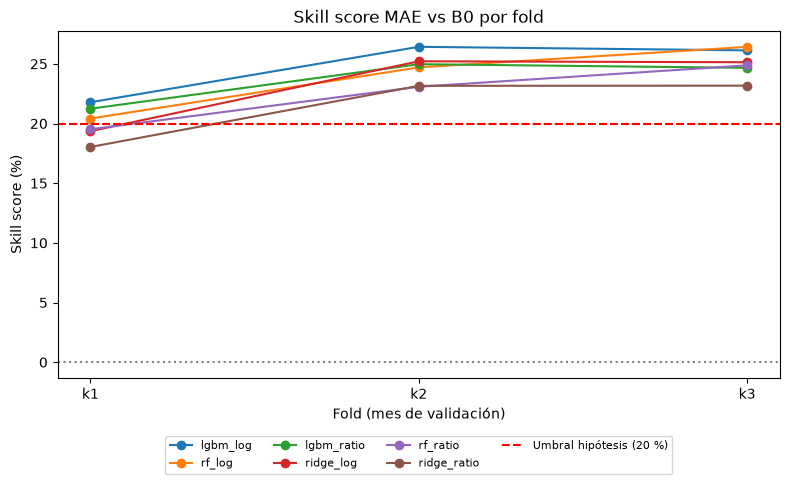

C:\Users\jaume\AppData\Local\Temp\ipykernel_12868\2946541117.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["k1", "k2", "k3"])


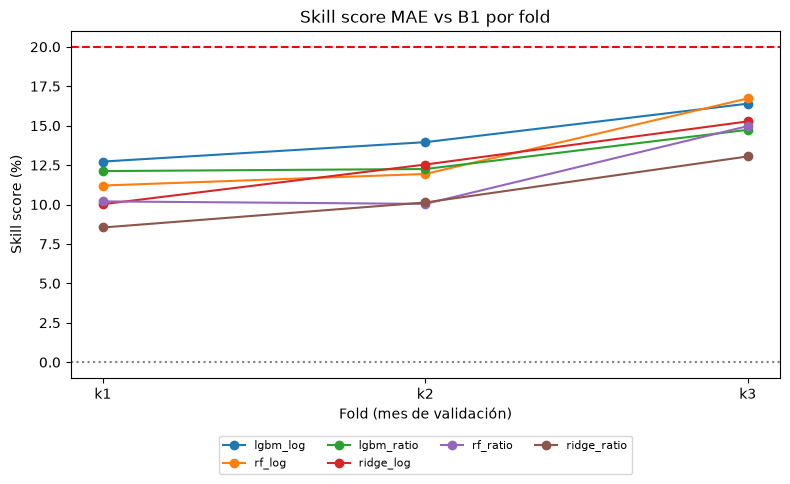

C:\Users\jaume\AppData\Local\Temp\ipykernel_12868\2946541117.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["k1", "k2", "k3"])


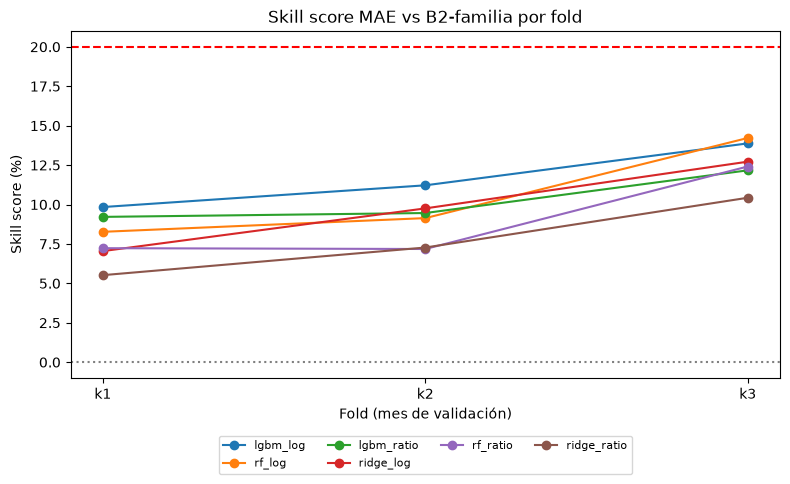

C:\Users\jaume\AppData\Local\Temp\ipykernel_12868\2946541117.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["k1", "k2", "k3"])


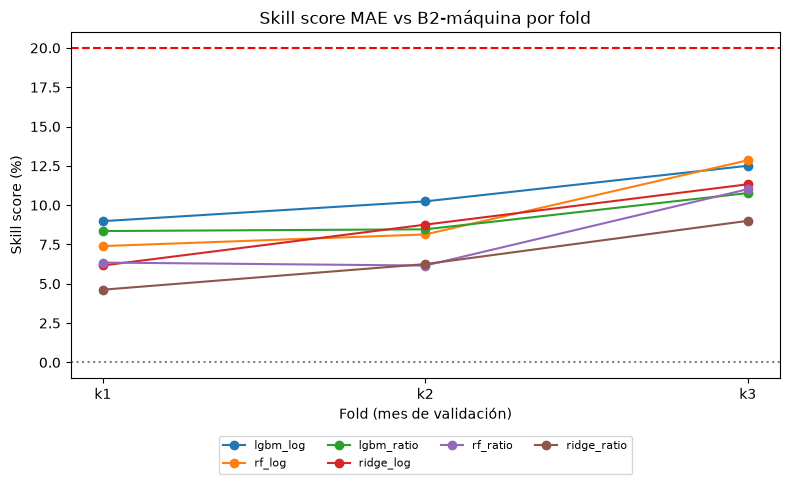

In [66]:
meses = ["2026-02", "2026-03", "2026-04"]

for b in baselines:
    modelos_t = tabla_MAE_final.drop(index=baselines)[meses]
    skill_fold = (1 - modelos_t / tabla_MAE_final.loc[b, meses]) * 100

    fig, ax = plt.subplots(figsize=(8, 5))
    for modelo, fila in skill_fold.iterrows():
        ax.plot(meses, fila, marker="o", label=modelo.replace("pred_", ""))

    ax.axhline(0, color="grey", linestyle=":")
    if b == "B0":
        ax.axhline(20, color="red", linestyle="--", label="Umbral hipótesis (20 %)")

    ax.set_title(f"Skill score MAE vs {b} por fold")
    ax.set_xlabel("Fold (mes de validación)")
    ax.set_ylabel("Skill score (%)")
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=4, fontsize=8)
    ax.set_xticklabels(["k1", "k2", "k3"]) 
     
    plt.axhline(y=20, color="red", linestyle="--", label="Corte")
    plt.tight_layout()
    plt.show()

#### Selección del modelo (con validación)

Se selecciona **LightGBM con objetivo log(ratio)** como modelo final:
- Obtiene el menor MAE medio en validación (0.835).
- El skill score de MAE frente a B0 supera el 20 % en los tres folds (mínimo en febrero, 21.8 %).
- Frente a B2-máquina, el baseline más exigente, reduce el MAE un 10.5 % de media.

Ridge-log, RF-ratio y Ridge-ratio cumplen el criterio con la media de los folds, pero no en febrero. En RMSE, las versiones log obtienen peores resultados que las versiones ratio; se asume este peor comportamiento en las desviaciones grandes a cambio de un menor error en la fase típica, coherente con la elección del MAE como métrica principal.

## Test

Ahora los 6 modelos se reentrenan con todo desarrollo y se evalúan en test con fines comparativos. El modelo seleccionado es LightGBM-log, se fijó con validación y no se modifica en función de los resultados de test.

In [67]:
ridge_t = pd.read_parquet("predicciones/ridge_test.parquet")
rf_t    = pd.read_parquet("predicciones/rf_test.parquet")
lgbm_t  = pd.read_parquet("predicciones/lgbm_test.parquet")

test_df = ridge_t[["IDMOTask", "ratio", "pred_ridge_ratio", "pred_ridge_log"]]

for d in [rf_t, lgbm_t, b0, b1, b2]:
    cols_pred = [c for c in d.columns if c.startswith("pred_")]
    test_df = test_df.merge(d[["IDMOTask"] + cols_pred], on="IDMOTask", how="left")

print(test_df.shape, test_df.isna().sum().sum())
display(test_df.head(0))

(2396, 15) 0


,IDMOTask,ratio,pred_ridge_ratio,pred_ridge_log,pred_rf_ratio,pred_rf_log,pred_lgbm_ratio,pred_lgbm_log,pred_B0,pred_B1_mediana,pred_B1_media,pred_B2_familia_mediana,pred_B2_familia_media,pred_B2_maquina_mediana,pred_B2_maquina_media


#### Error por modelo

In [68]:
# MAE en test (baselines con mediana)
filas_mae = []
for col in cols_MAE:
    m = metricas(test_df["ratio"], test_df[col])
    filas_mae.append({"prediccion": nombres.get(col, col), "MAE": m["MAE"]})

test_MAE = pd.DataFrame(filas_mae).sort_values("MAE")
display(test_MAE.round(3))
   
# RMSE en test (baselines con media)
filas_rmse = []
for col in cols_RMSE:
    m = metricas(test_df["ratio"], test_df[col])
    filas_rmse.append({"prediccion": nombres.get(col, col), "RMSE": m["RMSE"]})

test_RMSE = pd.DataFrame(filas_rmse).sort_values("RMSE")
display(test_RMSE.round(3))

,prediccion,MAE
5,pred_lgbm_log,0.785
3,pred_rf_log,0.791
1,pred_ridge_log,0.799
2,pred_rf_ratio,0.818
4,pred_lgbm_ratio,0.820
0,pred_ridge_ratio,0.837
9,B2-máquina,0.863
8,B2-familia,0.883
7,B1,0.905
6,B0,1.020


,prediccion,RMSE
2,pred_rf_ratio,1.134
4,pred_lgbm_ratio,1.137
0,pred_ridge_ratio,1.160
5,pred_lgbm_log,1.175
3,pred_rf_log,1.187
1,pred_ridge_log,1.211
9,B2-máquina,1.267
8,B2-familia,1.290
7,B1,1.321
6,B0,1.590


Los modelos en Test obtienen mejores resultados para las métricas de error que en Validación para MAE y RMSE. 

#### Skill

In [69]:
baselines = ["B0", "B1", "B2-familia", "B2-máquina"]
mae = test_MAE.set_index("prediccion")["MAE"]

filas = []
for modelo in mae.drop(baselines).index:
    fila = {"modelo": modelo}
    for b in baselines:
        fila[f"vs {b}"] = (1 - mae[modelo] / mae[b]) * 100
    filas.append(fila)

skill_test = pd.DataFrame(filas).sort_values("vs B0", ascending=False)
display(skill_test.round(1))

,modelo,vs B0,vs B1,vs B2-familia,vs B2-máquina
0,pred_lgbm_log,23.0,13.2,11.0,9.0
1,pred_rf_log,22.5,12.6,10.4,8.4
2,pred_ridge_log,21.7,11.7,9.5,7.5
3,pred_rf_ratio,19.8,9.6,7.4,5.3
4,pred_lgbm_ratio,19.6,9.4,7.1,5.0
5,pred_ridge_ratio,17.9,7.5,5.1,3.0


#### Evaluación en test y comprobación de la hipótesis

Los MAE de los baselines en test coinciden con los obtenidos en `10.1_Baselines`.

**Hipótesis.** El modelo seleccionado con validación, **LightGBM-log**, obtiene en test un skill score de MAE del **23.0 % frente a B0** (MAE 0.785 frente a 1.020). Supera el umbral del 20 % fijado antes de ver resultados, por lo que **la hipótesis se confirma**.

**Comparativa en test:**
- Los 6 modelos obtienen menor MAE y menor RMSE que todos los baselines.
- En MAE, las versiones log superan a las ratio para los tres modelos, igual que en validación. Solo las versiones log superan el 20 % frente a B0 (de 21.7 % a 23.0 %); las versiones ratio quedan entre 17.9 % y 19.8 %.
- En RMSE, las versiones ratio superan a las log para los tres modelos, igual que en validación.
- Frente a B2-máquina, el baseline más exigente, LightGBM-log reduce el MAE un 9.0 %.

**Respecto a validación**, el skill de LightGBM-log frente a B0 pasa de 24.7 % (media de folds) a 23.0 % en test, y frente a B2-máquina de 10.5 % a 9.0 %.

El error baja para los modelos y los baselines, también para B0, que no aprende nada. Este hecho sugiere que los meses de test son algo "más fáciles" de predecir: menos dispersión en el ratio. 

> Comprobarlo es fácil: compara la dispersión del ratio en validación y en test. (pendiente)

#### Análisis por segmentos (test)

In [70]:
df_split = pd.read_parquet("datos/df_split.parquet")
vars_seg = ["IDMOTask", "Familia Maquinas", "CodigoMaquina", "TipoFase", "TiempoPrevisto"]

cols_pred = ["pred_lgbm_log", "pred_B0", "pred_B1_mediana",
             "pred_B2_familia_mediana", "pred_B2_maquina_mediana"]

seg = test_df[["IDMOTask", "ratio"] + cols_pred].merge(
    df_split[vars_seg], on="IDMOTask", how="left")

# Error absoluto de cada fase
seg["err_modelo"] = (seg["pred_lgbm_log"] - seg["ratio"]).abs()
seg["err_B0"]     = (seg["pred_B0"] - seg["ratio"]).abs()
seg["err_B1"]     = (seg["pred_B1_mediana"] - seg["ratio"]).abs()
seg["err_B2_fam"] = (seg["pred_B2_familia_mediana"] - seg["ratio"]).abs()
seg["err_B2_maq"] = (seg["pred_B2_maquina_mediana"] - seg["ratio"]).abs()

print(seg.shape, seg.isna().sum().sum())
display(seg.sample(1))

(2396, 16) 0


,IDMOTask,ratio,pred_lgbm_log,pred_B0,pred_B1_mediana,pred_B2_familia_mediana,pred_B2_maquina_mediana,Familia Maquinas,CodigoMaquina,TipoFase,TiempoPrevisto,err_modelo,err_B0,err_B1,err_B2_fam,err_B2_maq
2309,71946267-afbd-40d9-bfac-31f3c9eff908,1.307111,0.995373,1.0,1.471014,1.224061,1.140243,TCN,TN07,TCN,150.0,0.311739,0.307111,0.163903,0.08305,0.166869


In [71]:
tabla_fam = seg.groupby("Familia Maquinas").agg(
    n          = ("ratio", "size"),
    MAE_modelo = ("err_modelo", "mean"),
    MAE_B0     = ("err_B0", "mean"),
    MAE_B1     = ("err_B1", "mean"),
    MAE_B2_fam = ("err_B2_fam", "mean"),
    MAE_B2_maq = ("err_B2_maq", "mean"),
)
for b in ["B0", "B1", "B2_fam", "B2_maq"]:
    tabla_fam[f"skill_vs_{b}"] = (1 - tabla_fam["MAE_modelo"] / tabla_fam[f"MAE_{b}"]) * 100

display(tabla_fam.sort_values("n", ascending=False).round(3))

,n,MAE_modelo,MAE_B0,MAE_B1,MAE_B2_fam,MAE_B2_maq,skill_vs_B0,skill_vs_B1,skill_vs_B2_fam,skill_vs_B2_maq
Familia Maquinas,,,,,,,,,,
TPU,701,0.857,1.246,1.073,1.051,0.985,31.232,20.173,18.489,13.040
MTP,560,0.933,1.144,0.965,0.956,0.954,18.449,3.283,2.389,2.201
CV,417,0.782,1.047,0.910,0.909,0.907,25.257,14.068,13.934,13.725
TCN,248,0.468,0.493,0.537,0.476,0.476,5.029,12.843,1.733,1.690
CH,171,0.527,0.556,0.672,0.578,0.587,5.217,21.644,8.911,10.226
C5,133,0.889,1.201,1.005,1.042,1.044,25.934,11.451,14.640,14.827
CV-ALU,71,0.517,0.575,0.669,0.572,0.574,10.173,22.755,9.723,9.962
CON,53,0.891,0.867,0.893,0.843,0.849,-2.808,0.161,-5.702,-5.035
FLEX,42,0.574,0.683,0.461,0.540,0.532,15.982,-24.343,-6.167,-7.855


#### Error por familia de máquina (test)

Las familias TPU, MTP y CV concentran el 70 % de las fases de test.

- **Mayor mejora frente a B0:** TPU (31.2 %), C5 (25.9 %) y CV (25.3 %), familias en las que el error del ERP es elevado (MAE_B0 > 1).
- **Menor mejora:** TCN (5.0 %), CH (5.2 %) y CV-ALU (10.2 %). Son las familias con menor error del ERP (MAE_B0 entre 0.49 y 0.58), por lo que el margen de mejora es reducido.
- MTP, la **segunda familia** en volumen, queda por debajo del 20 % frente a B0 (18.4 %) y apenas mejora a B2-máquina (2.2 %).
- CON (53 fases) obtiene **skill negativo** frente a B0 y B2, y **FLEX** (42 fases) frente a B2. Dado el tamaño reducido de estos grupos, estos resultados se interpretan con cautela.
- En TCN, CH y CV-ALU, B1 obtiene mayor error que B0: la corrección global del sesgo (≈1.47) desplaza al alza familias cuyo ratio típico está próximo a 1. En estas familias el modelo mejora claramente a B1 (12.8–22.8 %), aunque su mejora frente a B0 sea reducida.
- En FLEX (42 fases), B1 obtiene el menor error de todas las referencias, inferior también al del modelo.
- B2-familia y B2-máquina obtienen errores muy similares en todas las familias.
- En MTP la mejora del modelo frente a las referencias con información (B1, B2-familia, B2-máquina) es reducida (2.2–3.3 %).

In [72]:
# CM19 (máquina no vista) frente al resto de fases de test
seg["grupo_maquina"] = np.where(seg["CodigoMaquina"] == "CM19", "CM19 (no vista)", "Resto")

tabla_cm19 = seg.groupby("grupo_maquina").agg(
    n          = ("ratio", "size"),
    MAE_modelo = ("err_modelo", "mean"),
    MAE_B0     = ("err_B0", "mean"),
    MAE_B1     = ("err_B1", "mean"),
    MAE_B2_fam = ("err_B2_fam", "mean"),
    MAE_B2_maq = ("err_B2_maq", "mean"),
)
for b in ["B0", "B1", "B2_fam", "B2_maq"]:
    tabla_cm19[f"skill_vs_{b}"] = (1 - tabla_cm19["MAE_modelo"] / tabla_cm19[f"MAE_{b}"]) * 100

display(tabla_cm19.round(3))

,n,MAE_modelo,MAE_B0,MAE_B1,MAE_B2_fam,MAE_B2_maq,skill_vs_B0,skill_vs_B1,skill_vs_B2_fam,skill_vs_B2_maq
grupo_maquina,,,,,,,,,,
CM19 (no vista),36,1.029,1.471,1.190,1.180,1.190,30.073,13.567,12.846,13.567
Resto,2360,0.782,1.013,0.901,0.878,0.858,22.814,13.201,10.979,8.926


In [73]:
# saber a que familia pertenece la máquina CM19 
df_familias = pd.read_parquet("../res/procesed/maquina_grupo.parquet")

nombre_maquina = df_familias[df_familias["CodigoMaquina"]=="CM19"]["CodigoGrupo"].unique() 
print(F"La máquina CM19 pertenece a la familia: {nombre_maquina}") 


La máquina CM19 pertenece a la familia: ['CV']


CM19 es una máquina de la familia **CV** incorporada en mayo de 2026: aparece únicamente en test (36 fases) y no existe en desarrollo. En estas fases B2-máquina recurre al fallback (constante de B1), lo que se confirma en la tabla (MAE_B1 = MAE_B2_maq = 1.190).

- CM19 es un grupo más difícil que el resto: el ERP obtiene un MAE de 1.471 (resto: 1.013; familia CV: 1.047) y el modelo de 1.029 (resto: 0.782).
- El modelo reduce el MAE del ERP un 30.1 % en CM19 (resto: 22.8 %) y mejora a B2-familia un 12.8 % (resto: 11.0 %).

El modelo mantiene su mejora frente a todas las referencias en una máquina que no ha visto durante el entrenamiento, apoyándose en variables conocidas como la familia, el tipo de fase o el tiempo previsto. CV es una de las familias con más fases en desarrollo, lo que probablemente favorece este resultado; con máquinas nuevas de familias poco representadas el comportamiento podría ser distinto. Dado el tamaño reducido del grupo (36 fases), el resultado se considera orientativo.

#### Error por duración de la fase (test)
La duración se puede medir con el `TiempoPrevisto` por ERP. Mejor emplear este y no el real porque es lo que se conoce antes de producir.

In [74]:
# Tramos de duración: 5 grupos con el mismo número de fases
seg["tramo_duracion"] = pd.qcut(seg["TiempoPrevisto"], q=5)

tabla_dur = seg.groupby("tramo_duracion", observed=True).agg(
    n          = ("ratio", "size"),
    ratio_med  = ("ratio", "median"),
    MAE_modelo = ("err_modelo", "mean"),
    MAE_B0     = ("err_B0", "mean"),
    MAE_B1     = ("err_B1", "mean"),
    MAE_B2_fam = ("err_B2_fam", "mean"),
    MAE_B2_maq = ("err_B2_maq", "mean"),
)
for b in ["B0", "B1", "B2_fam", "B2_maq"]:
    tabla_dur[f"skill_vs_{b}"] = (1 - tabla_dur["MAE_modelo"] / tabla_dur[f"MAE_{b}"]) * 100

display(tabla_dur.round(3))

,n,ratio_med,MAE_modelo,MAE_B0,MAE_B1,MAE_B2_fam,MAE_B2_maq,skill_vs_B0,skill_vs_B1,skill_vs_B2_fam,skill_vs_B2_maq
tramo_duracion,,,,,,,,,,,
"(4.999, 16.0]",510,2.224,1.191,1.693,1.410,1.346,1.303,29.644,15.507,11.549,8.574
"(16.0, 32.0]",459,1.694,0.898,1.183,1.002,0.976,0.968,24.056,10.322,7.973,7.208
"(32.0, 70.0]",487,1.484,0.767,0.988,0.885,0.884,0.872,22.382,13.356,13.274,12.075
"(70.0, 113.0]",461,1.307,0.593,0.692,0.652,0.682,0.645,14.254,8.941,12.968,7.997
"(113.0, 974.0]",479,1.148,0.449,0.494,0.539,0.491,0.496,9.085,16.666,8.520,9.492


Las fases se agrupan en cinco tramos de tamaño similar (quintiles) según el tiempo previsto por el ERP.

- La mediana del ratio disminuye de forma continua con la duración, de 2.22 en las fases más cortas (5–16 min) a 1.15 en las más largas (>113 min), lo que confirma en test que las fases cortas presentan mayores desviaciones relativas. Esto es algo que ya se vio al estudiar el ratio.
- El error de todos los modelos y baselines disminuye con la duración (MAE del modelo de 1.191 a 0.449).
- El skill score frente a B0 decrece con la duración: 29.6 % en el tramo más corto y 9.1 % en el más largo. Supera el 20 % en las fases de hasta 70 minutos.
- Frente a B2 la mejora es positiva en todos los tramos (7.2–13.0 %).
- En el tramo más largo, B1 obtiene mayor error que B0, ya que la corrección global del sesgo sobreestima fases cuyo ratio típico está próximo a 1.

El modelo aporta la mayor mejora relativa en las fases cortas, donde el ERP infraestima más el tiempo real. Al estar medido en escala ratio, este análisis no refleja el impacto en tiempo absoluto, que se evalúa a continuación con el error en minutos.

#### Error en minutos

Pasar de ratio a minutos es directo:

    tiempo real      = ratio × TiempoPrevisto
    tiempo inferido  = ratio_inferido × TiempoPrevisto

    error en minutos = |ratio_inferido − ratio| × TiempoPrevisto

El error en minutos es el error en ratio multiplicado por la duración prevista de la fase, por lo que las fases largas pesan mucho más en minutos que en ratio.

In [75]:
display(seg.columns)

Index(['IDMOTask', 'ratio', 'pred_lgbm_log', 'pred_B0', 'pred_B1_mediana',
       'pred_B2_familia_mediana', 'pred_B2_maquina_mediana',
       'Familia Maquinas', 'CodigoMaquina', 'TipoFase', 'TiempoPrevisto',
       'err_modelo', 'err_B0', 'err_B1', 'err_B2_fam', 'err_B2_maq',
       'grupo_maquina', 'tramo_duracion'],
      dtype='object')

In [76]:
# Error absoluto en minutos de cada fase
for nombre in ["modelo", "B0", "B1", "B2_fam", "B2_maq"]:
    seg[f"min_{nombre}"] = seg[f"err_{nombre}"] * seg["TiempoPrevisto"]

# MAE en minutos sobre todo el test
mae_min = seg[["min_modelo", "min_B0", "min_B1", "min_B2_fam", "min_B2_maq"]].mean()
skill_min = (1 - mae_min["min_modelo"] / mae_min) * 100

display(pd.DataFrame({"MAE_minutos": mae_min, "skill_modelo_vs (%)": skill_min}).round(1))

,MAE_minutos,skill_modelo_vs (%)
min_modelo,41.9,0.0
min_B0,50.3,16.6
min_B1,50.8,17.4
min_B2_fam,48.5,13.5
min_B2_maq,47.7,12.2


In [ ]:
tabla_min = seg.groupby("tramo_duracion", observed=True).agg(
    n              = ("ratio", "size"),
    MAE_min_modelo = ("min_modelo", "mean"), # minutos de error medio por fase (modelo)
    MAE_min_B0     = ("min_B0", "mean"),     # minutos de error medio por fase (B0)
    MAE_min_B1     = ("min_B1", "mean"),     # minutos de error medio por fase (B1)
    total_min_B0   = ("min_B0", "sum"),      # minutos de error acumulados en el tramo (B0)
    total_min_mod  = ("min_modelo", "sum"),  # minutos de error acumulados en el tramo (modelo)
)
tabla_min["skill_vs_B0"]      = (1 - tabla_min["MAE_min_modelo"] / tabla_min["MAE_min_B0"]) * 100
tabla_min["%_error_total_B0"] = tabla_min["total_min_B0"] / tabla_min["total_min_B0"].sum() * 100
tabla_min["min_ahorrados"]    = tabla_min["total_min_B0"] - tabla_min["total_min_mod"]
display(tabla_min.round(2))

,n,MAE_min_modelo,MAE_min_B0,MAE_min_B1,total_min_B0,total_min_mod,skill_vs_B0,%_error_total_B0,min_ahorrados
tramo_duracion,,,,,,,,,
"(4.999, 16.0]",510,15.19,21.63,17.97,11030.23,7748.34,29.75,9.16,3281.89
"(16.0, 32.0]",459,21.42,28.51,24.17,13084.49,9831.91,24.86,10.87,3252.58
"(32.0, 70.0]",487,39.47,50.06,45.45,24379.23,19223.23,21.15,20.25,5156.00
"(70.0, 113.0]",461,52.60,61.03,57.82,28136.79,24248.96,13.82,23.37,3887.84
"(113.0, 974.0]",479,82.28,91.38,109.86,43769.60,39413.77,9.95,36.35,4355.83


En minutos, el modelo se equivoca de media 41.9 min por fase frente a 50.3 min del ERP (B0), un skill score del 16.6 %. En minutos, B1 (50.8 min) obtiene un error ligeramente superior al de B0.

Por tramos de duración:
- El skill score en minutos frente a B0 decrece con la duración, de 29.75 % en las fases más cortas (5–16 min) a 9.95 % en las más largas (>113 min).
- El error total del ERP se concentra en las fases largas: el tramo de más de 113 min acumula el 36.35 % de los minutos de error y el de 70–113 min el 23.37 %, frente al 9.16 % de las fases más cortas.
- El modelo reduce los minutos de error en los cinco tramos; el mayor ahorro se produce en el tramo de 32–70 min (5156 min).

La mejora en minutos (16.6 %) es menor que en ratio (23.0 %): la mayor mejora relativa del modelo se da en fases cortas, que concentran una parte pequeña del error total en minutos. 

> La hipótesis, definida sobre el ratio, no se ve afectada, pero este resultado acota el impacto esperado en tiempo real de planta.

### SHAP

LightGBM funciona como una caja negra, SHAP ayuda a visualizar el peso de cada variable en el resultado de la predicción al inferir.    

Debe tenerse en cuenta que el modelo final trabaja con el log del ratio, no con el ratio. Entonces SHAP reparte la predicción en escala log y eso debera convertirse.  

> El estudio SHAP se ejecuta en el notebook `10.4_LightGBM` concretamente despues del analisis para el Test. 